# SCDF-14: ABC-XYZ Matrix Visualization

**Sprint 2 · Epic SCDF-E2 · Portfolio Artifact: Hero Visual \#1**

This notebook walks through building the 3x3 ABC-XYZ segmentation heatmap, the
first hero visual in the portfolio writeup. It builds on the `classify_abc`
and `classify_xyz` functions from SCDF-12/13 to produce a chart that
communicates inventory strategy at a glance.

**What this notebook covers:**

1. Preparing M5 data in the long format the classifiers expect
2. Applying ABC and XYZ classification
3. Aggregating per-cell statistics (SKU count, % share, avg revenue)
4. Building the heatmap with Catppuccin color palette
5. Annotating each cell with MTS/MTO policy from SCDF-15
6. Saving the figure as PNG

## Setup

Run this notebook from within the `.local/` directory. We add the project root
to `sys.path` so imports from `src/` work.

In [1]:
# Add project root to path to allow importing from `src/`
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from pandas import DataFrame

In [3]:
# Setup autoreloading to update any changes to `src`
%load_ext autoreload
%autoreload all

In [4]:
from src.segmentation import classify_abc, classify_xyz
from src.plotting import configure_matplotlib

configure_matplotlib()  # activates Catppuccin Latte theme

## Load & Prepare Data

The M5 dataset is in **wide format** — each row is a SKU-store combination and
each day has its own column (`d_1`, `d_2`, …, `d_1941`). Both classifier
functions expect **long format** with one row per (item, store, day).

We also need two joins:

- `calendar.csv` → maps `d_*` column names to actual dates and `wm_yr_wk`
  (week ID)
- `sell_prices.csv` → weekly sell price per (item, store, week), needed for sales

In [5]:
DATA_DIR = Path("../data").resolve()

sales = pd.read_csv(f"{DATA_DIR}/sales_train_evaluation.csv")
calendar = pd.read_csv(f"{DATA_DIR}/calendar.csv")
prices = pd.read_csv(f"{DATA_DIR}/sell_prices.csv")

print(f"Sales:    {sales.shape[0]:,} rows × {sales.shape[1]:,} cols")
print(f"Calendar: {calendar.shape}")
print(f"Prices:   {prices.shape}")

Sales:    30,490 rows × 1,947 cols
Calendar: (1969, 14)
Prices:   (6841121, 4)


In [6]:
def preprocess_sales_data(
    sales: DataFrame,
    calendar: DataFrame,
    prices: DataFrame,
) -> DataFrame:
    """
    Convert wide to long-from and merge supplemental data.
    """
    df = sales.melt(
        id_vars=["item_id", "dept_id", "cat_id", "store_id", "state_id"],
        value_vars=[c for c in sales.columns if c.startswith("d_")],
        var_name="d",
        value_name="sales_quantity",
    )
    df = df.merge(
        calendar[["d", "date", "wm_yr_wk"]],
        on="d",
        how="left",
    )
    df = df.merge(
        prices[["store_id", "item_id", "wm_yr_wk", "sell_price"]],
        on=["store_id", "item_id", "wm_yr_wk"],
        how="left",
    )
    df["sales_amount"] = df["sales_quantity"].mul(df["sell_price"]).fillna(0)
    return df


# Filter for subset for fasting processing
df = preprocess_sales_data(sales, calendar, prices)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59181090 entries, 0 to 59181089
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   item_id         object 
 1   dept_id         object 
 2   cat_id          object 
 3   store_id        object 
 4   state_id        object 
 5   d               object 
 6   sales_quantity  int64  
 7   date            object 
 8   wm_yr_wk        int64  
 9   sell_price      float64
 10  sales_amount    float64
dtypes: float64(2), int64(2), object(7)
memory usage: 4.9+ GB


,item_id,dept_id,cat_id,store_id,state_id,d,sales_quantity,date,wm_yr_wk,sell_price,sales_amount
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,0.0
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,0.0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,0.0
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,0.0
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,0.0


## ABC Classification

`classify_abc` sorts items within each store by descending revenue, computes
cumulative Pareto share, and assigns tiers:

- **A**: top 70% of cumulative revenue (highest-value items)
- **B**: next 20% (70-90%)
- **C**: remainder (bottom 10% of revenue)

The classification is **per-store** — so an item's tier can differ across
stores if its relative revenue contribution differs. This matches real supply
chain practice: what's an A item in one region might be C in another.

In [7]:
df_abc = classify_abc(df, sales_col="sales_amount")
if df_abc["abc_class"].isna().sum() > 0:
    raise ValueError("Unexpected nulls in abc_class")

# One row per unique SKU-store pair (abc_class is the same for all rows of the same SKU)
sku_abc = df_abc.groupby(["store_id", "item_id"])["abc_class"].first().reset_index()

print("ABC class distribution (unique SKU-store combinations):")
counts = sku_abc["abc_class"].value_counts().sort_index()
for cls, n in counts.items():
    print(f"  {cls}: {n:,} SKUs ({n / len(sku_abc):.1%})")

ABC class distribution (unique SKU-store combinations):
  A: 8,084 SKUs (26.5%)
  B: 8,732 SKUs (28.6%)
  C: 13,674 SKUs (44.8%)


## XYZ Classification

`classify_xyz` measures demand variability using **coefficient of variation
(CV)**, computed on weekly-aggregated sales for each SKU-store pair:

$$CV = \frac{\sigma_{\text{weekly demand}}}{\mu_{\text{weekly demand}}}$$

- **X**: CV < 0.5 — predictable, steady demand → good candidates for lean stock
  policies
- **Y**: 0.5 ≤ CV < 1.0 — moderate variability → requires some safety stock
  buffer
- **Z**: CV ≥ 1.0 — erratic or intermittent demand → hard to forecast, MTO
  candidates

Zero-demand items produce CV = undefined (0/0 = NaN), which defaults to **Z** —
the most conservative classification. This is intentional: if we have no demand
history, we should not commit stock.

In [10]:
df_xyz = classify_xyz(df_abc, demand_col="sales_amount", date_col="date")

assert df_xyz["xyz_class"].isna().sum() == 0, "Unexpected nulls in xyz_class"

item_xyz = df_xyz.groupby(["store_id", "item_id"])["xyz_class"].first().reset_index()

print("XYZ class distribution (unique SKU-store combinations):")
counts = item_xyz["xyz_class"].value_counts().sort_index()
for cls, n in counts.items():
    print(f"  {cls}: {n:,} SKUs ({n / len(item_xyz):.1%})")

XYZ class distribution (unique SKU-store combinations):
  X: 1,166 SKUs (3.8%)
  Y: 11,627 SKUs (38.1%)
  Z: 17,697 SKUs (58.0%)


## Summary Matrix

The heatmap needs per-cell aggregates. We first collapse to one row per unique
item-store combination (dropping the day-level rows), then group by the 9
ABC-XYZ cells:

In [11]:
def build_matrix_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate a classified long-format dataframe to per-cell statistics.

    Parameters
    ----------
    df : DataFrame
        Long-format df with abc_class, xyz_class, and sales columns.

    Returns
    -------
    DataFrame with one row per ABC-XYZ cell:
        abc_class, xyz_class, item_count, pct_items, avg_sales
    """
    # Collapse to one row per unique SKU-store pair
    item_level = (
        df.assign(abc_xyz_class=df["abc_class"] + df["xyz_class"])
        .groupby(["store_id", "item_id"])
        .agg(
            abc_xyz_class=("abc_xyz_class", "first"),
            total_sales=("sales_amount", "sum"),
        )
        .reset_index()
    )
    n_items = len(item_level)
    summary = (
        item_level.groupby("abc_xyz_class")
        .agg(
            item_count=("item_id", "count"),
            avg_sales=("total_sales", "mean"),
        )
        .sort_index()
        .reset_index()
    )
    summary["pct_items"] = summary["item_count"] / n_items
    return summary


matrix = build_matrix_summary(df_xyz)
matrix

,abc_xyz_class,item_count,avg_sales,pct_items
0,AX,1009,25751.401130,0.033093
1,AY,5213,15623.120610,0.170974
2,AZ,1862,14305.561686,0.061069
3,BX,143,6153.720629,0.004690
4,BY,4673,4637.960824,0.153263
5,BZ,3916,4032.764860,0.128436
6,CX,14,3270.932143,0.000459
7,CY,1741,2225.591465,0.057101
8,CZ,11919,1279.307890,0.390915


## MTS/MTO Policy Table

Each ABC-XYZ cell maps to an inventory policy. These rules come from SCDF-15:

| Cell | Policy | Service Level | Rationale |
|------|--------|---------------|-----------|
| AX | MTS | 99% | High value + predictable: always in stock, maximize fill rate |
| AY | MTS | 99% | High value: worth the safety stock cost despite moderate variability |
| BX | MTS | 99% | Predictable enough to stock reliably at mid-tier revenue |
| AZ | MTS | 95% | High value but erratic: stock conservatively, monitor closely |
| BY | MTS | 95% | Standard policy for mid-value, moderate variability |
| CX | MTS | 95% | Low value but predictable: standard MTS |
| BZ | MTS/review | 90% | Mid-value + erratic: consider MTO trigger at reorder point |
| CY | MTS/review | 90% | Low value + moderate variability: regular review cycle |
| CZ | MTO | — | Low value + erratic: make to order only, or discontinue |

In [14]:
def assign_policy(abc_xyz: pd.Series) -> pd.Series:
    policy = np.select(
        [abc_xyz == "CZ", abc_xyz.isin(["BZ", "CY"])],
        ["MTO", "MTS+Review"],
        default="MTS",
    )
    return pd.Series(policy, index=abc_xyz.index)


def assign_service_level(abc_xyz: pd.Series) -> pd.Series:
    service_level = np.select(
        [
            abc_xyz.isin(["AX", "AY", "BX"]),
            abc_xyz.isin(["AZ", "BY", "CX"]),
            abc_xyz.isin(["BZ", "CY"]),
        ],
        [0.99, 0.95, 0.90],
        default=np.nan,  # CZ
    )
    return pd.Series(service_level, index=abc_xyz.index)


matrix["policy"] = assign_policy(matrix["abc_xyz_class"])
matrix["service_level"] = assign_service_level(matrix["abc_xyz_class"])

matrix

,abc_xyz_class,item_count,avg_sales,pct_items,policy,service_level
0,AX,1009,25751.401130,0.033093,MTS,0.99
1,AY,5213,15623.120610,0.170974,MTS,0.99
2,AZ,1862,14305.561686,0.061069,MTS,0.95
3,BX,143,6153.720629,0.004690,MTS,0.99
4,BY,4673,4637.960824,0.153263,MTS,0.95
5,BZ,3916,4032.764860,0.128436,MTS+Review,0.90
6,CX,14,3270.932143,0.000459,MTS,0.95
7,CY,1741,2225.591465,0.057101,MTS+Review,0.90
8,CZ,11919,1279.307890,0.390915,MTO,NaN


## Heatmap

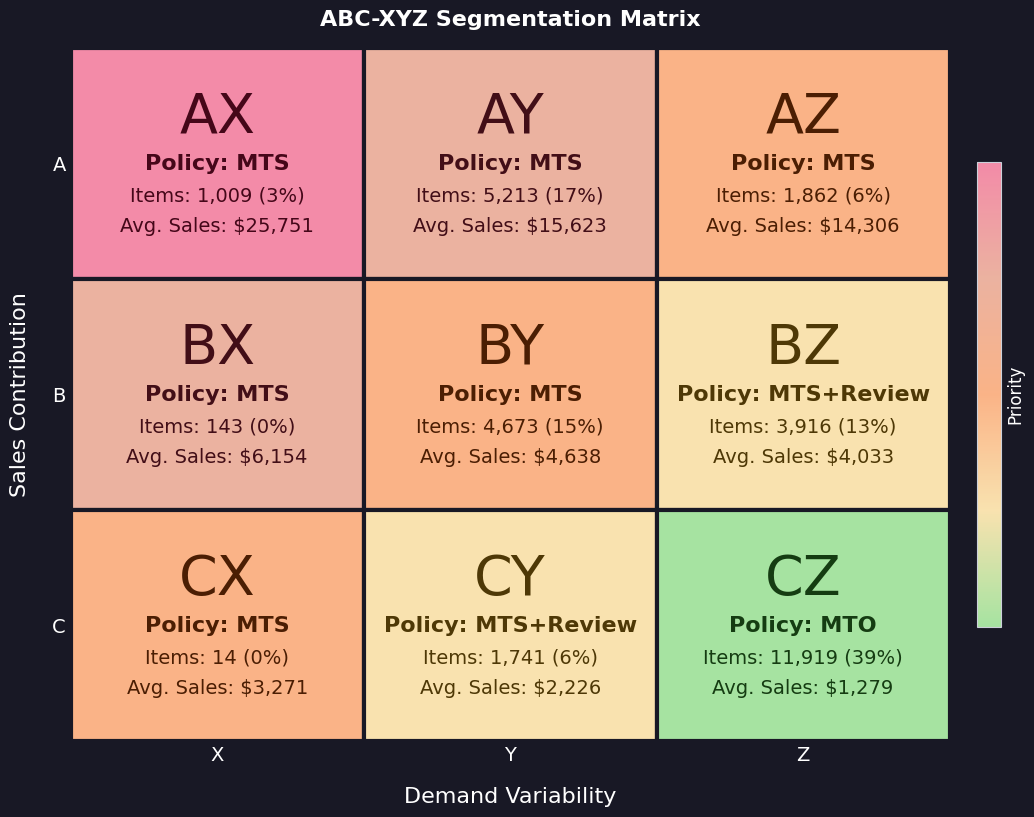

In [20]:
def build_abcxyz_heatmap(
    matrix_df: DataFrame,
    figsize: tuple = (12, 9),
    title: str = "ABC-XYZ Segmentation Matrix",
) -> tuple[plt.Figure, plt.Axes]:
    df = matrix_df.set_index("abc_xyz_class")

    # Define heatmap colors
    mantle = "#181825"
    text = "#ffffff"
    rect_colors = ["#f38ba8", "#ebb2a0", "#fab387", "#f9e2af", "#a6e3a1"]
    font_colors = ["#450719", "#420e17", "#4b1e03", "#4e3806", "#153c12"]
    class_priorities = dict(
        AX=1,
        AY=2,
        AZ=3,
        BX=2,
        BY=3,
        BZ=4,
        CX=3,
        CY=4,
        CZ=5,
    )

    fig, ax = plt.subplots(figsize=figsize)
    for idx, (cls, priority) in enumerate(class_priorities.items()):
        x, y = idx % 3, idx // 3
        rect_color = rect_colors[priority - 1]
        font_color = font_colors[priority - 1]

        ax.add_patch(
            mpatches.Rectangle(
                (x, y),
                width=1,
                height=1,
                facecolor=rect_color,
                edgecolor=mantle,
                linewidth=3,
            )
        )

        row = df.loc[cls]
        ax.text(
            x + 0.5,
            y + 0.30,
            cls,
            ha="center",
            va="center",
            fontsize=40,
            color=font_color,
        )
        ax.text(
            x + 0.5,
            y + 0.5,
            f"Policy: {row.policy}",
            ha="center",
            va="center",
            fontsize=16,
            color=font_color,
            fontweight="bold",
        )
        ax.text(
            x + 0.5,
            y + 0.64,
            f"Items: {row.item_count:,.0f} ({row.pct_items:.0%})",
            ha="center",
            va="center",
            fontsize=14,
            color=font_color,
        )
        ax.text(
            x + 0.5,
            y + 0.77,
            f"Avg. Sales: ${row.avg_sales:,.0f}",
            ha="center",
            va="center",
            fontsize=14,
            color=font_color,
        )

    # Create color bar
    sm = plt.cm.ScalarMappable(
        norm=plt.Normalize(vmin=0, vmax=9),
        cmap=LinearSegmentedColormap.from_list("", rect_colors[::-1], N=256),
    )
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.03)
    cbar.set_label("Priority", fontsize=12, color=text)
    cbar.set_ticks([])

    # Format axes
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.invert_yaxis()  # A at Top, C at Bottom
    ax.set_xticks([0.5, 1.5, 2.5], ["X", "Y", "Z"], fontsize=14, color=text)
    ax.set_yticks([0.5, 1.5, 2.5], ["A", "B", "C"], fontsize=14, color=text)
    ax.tick_params(length=0)
    ax.set_xlabel("Demand Variability", color=text, fontsize=16, labelpad=16)
    ax.set_ylabel("Sales Contribution", color=text, fontsize=16, labelpad=16)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=16, color=text)
    ax.spines[:].set_visible(False)

    fig.set_facecolor(mantle)
    return fig, ax


fig, ax = build_abcxyz_heatmap(matrix)
plt.show()

In [21]:
OUTPUT_DIR = Path("../outputs").resolve()
OUTPUT_DIR.mkdir(exist_ok=True)

output_path = OUTPUT_DIR / "abcxyz_matrix.svg"
fig.savefig(output_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Saved: {output_path}")

Saved: /home/matt/Programming/repos/sc-demand-forecasting/outputs/abcxyz_matrix.svg
